In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2FwdXJ2YW5ha2FkZS9HaXRodWIvc2Vjb25kLWRyYWZ0cy9kcmFmdHM='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/apurvanakade/miniconda3/lib/python3.12/importlib/_bootstrap.py": 1708117302.8894389, "/Users/apurvanakade/miniconda3/lib/python3.12/importlib/_bootstrap_external.py": 1708117302.895673, "/Users/apurvanakade/miniconda3/lib/python3.12/zipimport.py": 1708117300.842618, "/Users/apurvanakade/miniconda3/lib/python3.12/codecs.py": 1708117300.2231953, "/Users/apurvanakade/miniconda3/lib/python3.12/encodings/aliases.py": 1708117301.4904184, "/Users/apurvanakade/miniconda3/lib/python3.12/encodings/__init__.py": 1708117301.4862745, "/Users/apurvanakade/miniconda3/lib/python3.12/encodings/utf_8.py": 1708117302.0979323, "/Users/apurvanakade/miniconda3/lib/python3.12/abc.py": 1708117300.1248448, "/Users/apurvanakade/miniconda3/lib/python3.12/io.py": 1708117300.4300423, "/Users/apurvanakade/miniconda3/lib/python3.12/stat.py": 1708117300.6806324, "/Users/apurvanakade/miniconda3/lib/python3.12/_collections_abc.py": 1708117300.0486746, "/Users/apurvanakade/miniconda3/lib/python3.12/genericpath.

/var/folders/2y/zsgtjj415jdb0d4y2b_wx7th0000gn/T/ipykernel_89442/64115663.py:25: DeprecationWarning:

`set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`



In [2]:
def find_cycle(n):
  list = [0, 1]
  current = 1
  while True:
    list.append(current)
    current = (list[-1] + list[-2]) % n
    if current == 0:
      return list

def find_cycle_length(n):
  first = 0
  second = 1
  # current = 1
  counter = 2
  while True:
    current = (first + second) % n
    if current == 0:
      return counter
    first = second
    second = current
    counter +=1


In [3]:
# n = 5

ok_nums = []

good_nums = []

very_good_nums = []

for n in range(3, 10000):
  cycle_length = find_cycle_length(n)
  if cycle_length % n == 0:
    ok_nums.append(n)
  if n % cycle_length == 0:
    good_nums.append(n)
  if cycle_length == n:
    very_good_nums.append(n)

print(f"Ok numbers: {ok_nums}")
print(f"Good numbers: {good_nums}")
print(f"Very Good numbers: {very_good_nums}")

Ok numbers: [5, 6, 12, 25, 30, 60, 125, 150, 300, 625, 750, 1500, 3125, 3750, 7500]
Good numbers: [5, 12, 24, 25, 36, 48, 60, 72, 96, 108, 120, 125, 144, 168, 180, 192, 216, 240, 288, 300, 324, 336, 360, 384, 432, 480, 504, 540, 552, 576, 600, 612, 625, 648, 660, 672, 684, 720, 768, 840, 864, 900, 960, 972, 1008, 1080, 1104, 1152, 1176, 1200, 1224, 1296, 1320, 1344, 1368, 1440, 1500, 1512, 1536, 1620, 1656, 1680, 1728, 1800, 1836, 1860, 1920, 1944, 1980, 2016, 2052, 2160, 2184, 2208, 2256, 2304, 2352, 2400, 2448, 2460, 2520, 2592, 2640, 2688, 2700, 2736, 2760, 2880, 2916, 3000, 3024, 3060, 3072, 3125, 3240, 3300, 3312, 3360, 3420, 3456, 3528, 3600, 3660, 3672, 3720, 3840, 3852, 3864, 3888, 3960, 4032, 4104, 4200, 4320, 4368, 4416, 4500, 4512, 4536, 4608, 4704, 4800, 4860, 4872, 4896, 4920, 4968, 5040, 5184, 5280, 5376, 5400, 5472, 5508, 5520, 5580, 5724, 5760, 5832, 5880, 5940, 6000, 6048, 6120, 6144, 6156, 6480, 6552, 6600, 6624, 6720, 6768, 6840, 6912, 7056, 7200, 7260, 7320, 7344, 7

Calculating Fibonacci entry points...
Fibonacci Entry Points α(n) - first k where F_k ≡ 0 (mod n):
n	α(n)	F_α(n) mod n verification
----------------------------------------
1	1	F_1 ≡ 0 (mod 1)
2	3	F_3 ≡ 1 (mod 2)
3	4	F_4 ≡ 2 (mod 3)
4	6	F_6 ≡ 1 (mod 4)
5	5	F_5 ≡ 3 (mod 5)
6	12	F_12 ≡ 5 (mod 6)
7	8	F_8 ≡ 6 (mod 7)
8	6	F_6 ≡ 5 (mod 8)
9	12	F_12 ≡ 8 (mod 9)
10	15	F_15 ≡ 7 (mod 10)
11	10	F_10 ≡ 1 (mod 11)
12	12	F_12 ≡ 5 (mod 12)
13	7	F_7 ≡ 8 (mod 13)
14	24	F_24 ≡ 13 (mod 14)
15	20	F_20 ≡ 11 (mod 15)

Verification of specific cases:
α(5) = 5 (first k where 5 | F_k)
α(12) = 12 (first k where 12 | F_k)



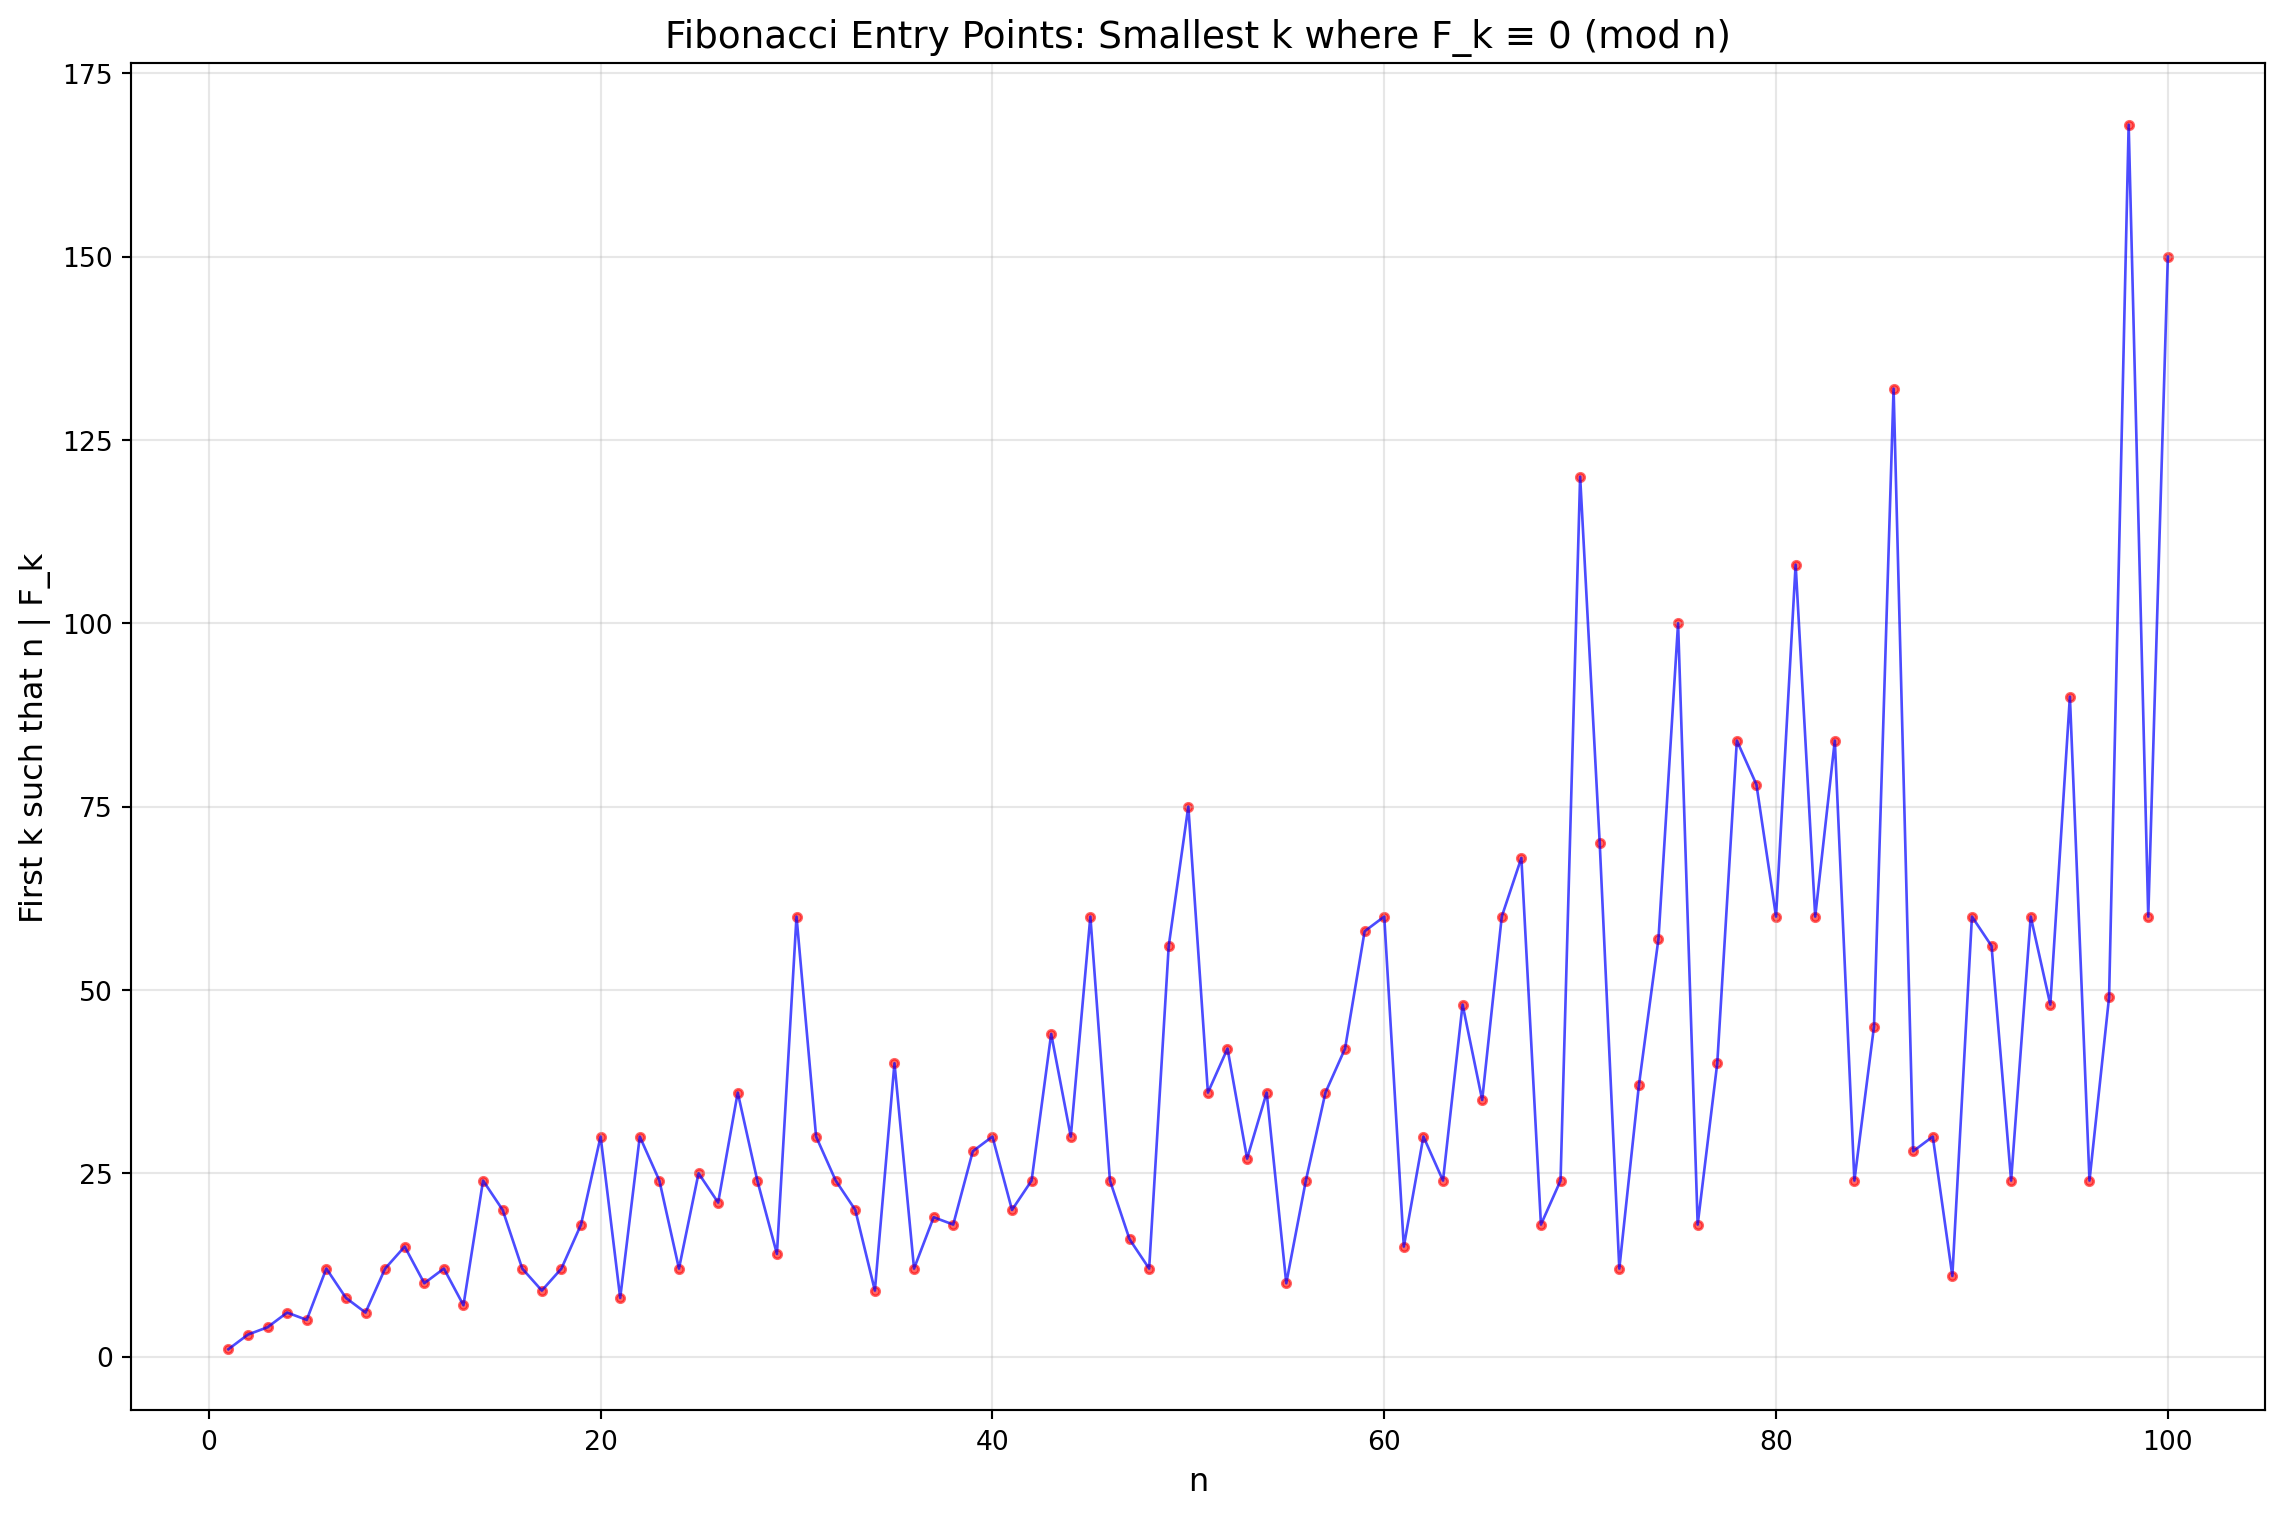

Statistics for n = 1 to 100:
Average entry point: 37.51
Maximum entry point: 168 (at n = 98)
Minimum entry point: 1


In [4]:
import matplotlib.pyplot as plt
import numpy as np

def fibonacci_entry_point(n):
    """
    Find the smallest k such that F_k ≡ 0 (mod n), where F_k is the k-th Fibonacci number.
    This is called the entry point or rank of apparition of n in the Fibonacci sequence.
    
    Args:
        n: The modulus
    
    Returns:
        The smallest k such that n divides F_k
    """
    if n == 1:
        return 1  # F_1 = 1 ≡ 0 (mod 1)
    
    if n == 2:
        return 3  # F_3 = 2 ≡ 0 (mod 2)
    
    # Start with F_0 = 0, F_1 = 1
    prev, curr = 0, 1
    k = 0
    
    # Check F_0 first
    if prev % n == 0 and k > 0:  # Skip k=0 case typically
        return k
    
    # Generate Fibonacci numbers until we find one divisible by n
    for k in range(1, 6 * n + 1):  # Upper bound
        if curr % n == 0:
            return k
        prev, curr = curr, (prev + curr) % n
    
    return -1  # Should never reach here for valid input

def plot_fibonacci_entry_points(max_n=100):
    """
    Plot the Fibonacci entry points for integers from 1 to max_n.
    
    Args:
        max_n: Maximum value of n to compute
    """
    n_values = list(range(1, max_n + 1))
    entry_points = [fibonacci_entry_point(n) for n in n_values]
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    plt.plot(n_values, entry_points, 'b-', linewidth=1, alpha=0.7)
    plt.scatter(n_values, entry_points, c='red', s=10, alpha=0.6)
    
    plt.xlabel('n', fontsize=12)
    plt.ylabel('First k such that n | F_k', fontsize=12)
    plt.title('Fibonacci Entry Points: Smallest k where F_k ≡ 0 (mod n)', fontsize=14)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    return n_values, entry_points

def print_some_entry_points(max_n=20):
    """
    Print the first few Fibonacci entry points for verification.
    """
    print("Fibonacci Entry Points α(n) - first k where F_k ≡ 0 (mod n):")
    print("n\tα(n)\tF_α(n) mod n verification")
    print("-" * 40)
    
    for n in range(1, max_n + 1):
        entry_point = fibonacci_entry_point(n)
        
        # Verify by computing F_k mod n
        a, b = 0, 1
        for k in range(entry_point):
            if k == 0:
                fib_k = a
            else:
                a, b = b, (a + b)
                fib_k = a
        
        print(f"{n}\t{entry_point}\tF_{entry_point} ≡ {fib_k % n} (mod {n})")

# Calculate and plot
print("Calculating Fibonacci entry points...")

# Print first few entry points for verification
print_some_entry_points(15)
print()

# Verify the specific cases you mentioned
print("Verification of specific cases:")
print(f"α(5) = {fibonacci_entry_point(5)} (first k where 5 | F_k)")
print(f"α(12) = {fibonacci_entry_point(12)} (first k where 12 | F_k)")
print()

# Plot the entry points
n_vals, entry_points = plot_fibonacci_entry_points(100)

# Print some statistics
print(f"Statistics for n = 1 to 100:")
print(f"Average entry point: {np.mean(entry_points):.2f}")
print(f"Maximum entry point: {max(entry_points)} (at n = {n_vals[np.argmax(entry_points)]})")
print(f"Minimum entry point: {min(entry_points)}")